In [13]:
from modules.visual.detector import VATSA_Detector
print(dir(VATSA_Detector))  # should show 'visualise' in the list

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'detect_and_crop']


In [1]:
import inspect
from modules.visual.detector import VATSA_Detector
print(inspect.getsource(VATSA_Detector))

class VATSA_Detector:
    def __init__(self, model_name="yolov8n.pt", conf_threshold=0.3):
        self.model = YOLO(model_name)
        self.conf_threshold = conf_threshold

        self.crop_transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

    def detect_and_crop(self, pil_image):
        results = self.model(pil_image, conf=self.conf_threshold)[0]
        regions = []

        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0])
            label = results.names[int(box.cls[0])]
            crop = pil_image.crop((x1, y1, x2, y2))
            crop_tensor = self.crop_transform(crop)

            regions.append({
                "label": label,
                "confidence": conf,
                "cr


0: 448x640 6 persons, 54.3ms
Speed: 33.9ms preprocess, 54.3ms inference, 13.0ms postprocess per image at shape (1, 3, 448, 640)
person (0.92) → embedding shape: torch.Size([512])
person (0.85) → embedding shape: torch.Size([512])
person (0.81) → embedding shape: torch.Size([512])
person (0.74) → embedding shape: torch.Size([512])
person (0.72) → embedding shape: torch.Size([512])
person (0.62) → embedding shape: torch.Size([512])
Saved to output.jpg


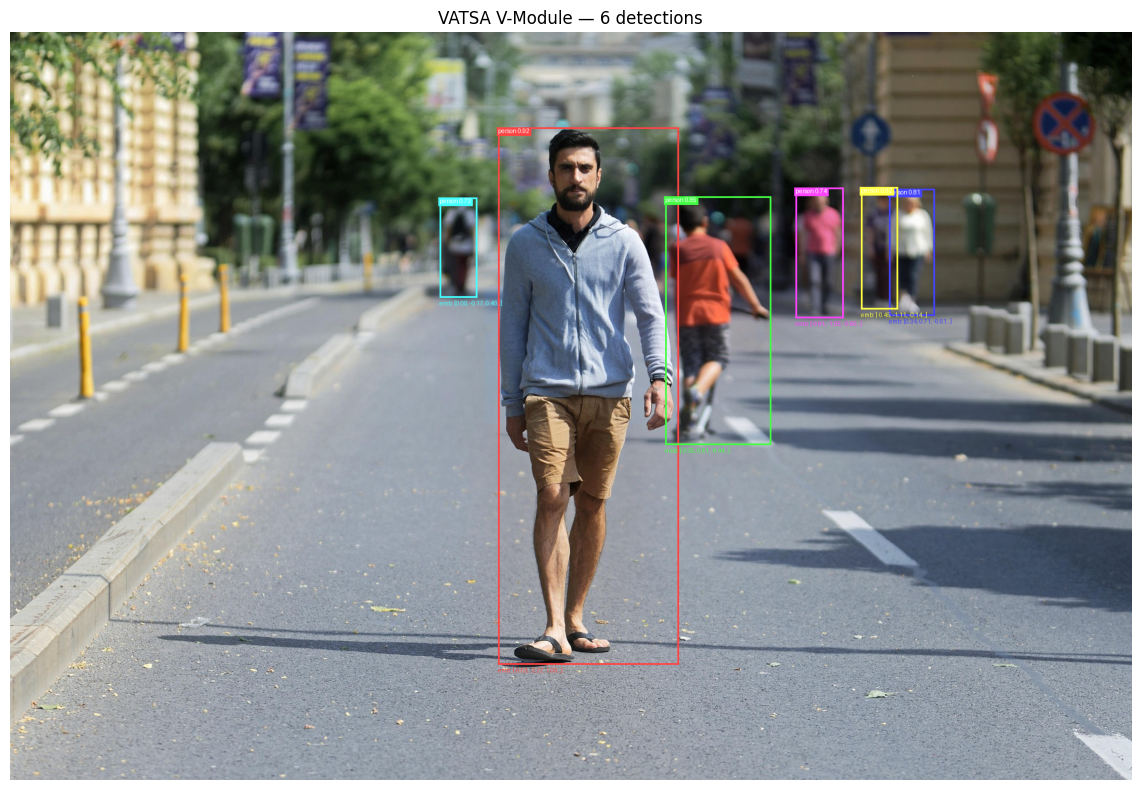

: 

In [ ]:
import sys
sys.path.append(r"C:\Users\vinay\OneDrive\Desktop\VATSA\VATSA")

from modules.visual.encoder import VATSA_VisualEncoder
from modules.visual.detector import VATSA_Detector
from modules.visual.visual_pipeline import VATSA_VisualPipeline
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from PIL import Image
from modules.visual.visual_pipeline import VATSA_VisualPipeline

pipeline = VATSA_VisualPipeline(
    encoder_path="vatsa_visual_encoder_cifar10_deeper_unfreeze.pth",
    device="cuda"
)

image = Image.open(r"C:\Users\vinay\OneDrive\Desktop\VATSA\VATSA\notebooks\test_img\man.jpg").convert("RGB")
results = pipeline.process_image(image)

for r in results:
    print(f"{r['label']} ({r['confidence']:.2f}) → embedding shape: {r['embedding'].shape}")
    # Output: car (0.91) → embedding shape: torch.Size([512])
annotated = pipeline.detector.visualise(image, results, save_path="output.jpg")

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"VATSA V-Module — {len(results)} detections")
plt.tight_layout()
plt.show()